> **Uso de IAG en este proyecto**  
> Este cuaderno fue desarrollado como parte del proyecto de grado  
> *"Análisis de temblor con sensores inerciales (IMU) para la detección de inestabilidad postural en pacientes con Parkinson"*.  
> Se utilizaron herramientas de Inteligencia Artificial Generativa (IAG)  
> -- GitHub Copilot y OpenCode (modelo deepseek-v4-flash) -- para:  
> - Generación y depuración de código Python (carga de datos, preprocesamiento, análisis espectral, visualización).  
> - Asistencia en estructuración de cuadernos Jupyter y documentación técnica.  
> - Revisión de lógica de detección de temblor y clasificación MDS-UPDRS.  
>  
> Todo el código generado fue revisado, validado y ajustado por los autores  
> para garantizar su corrección técnica y alineación con los objetivos clínicos del estudio.  
>  
> **Citación:** Herramientas de IAG (GitHub Copilot, OpenCode) utilizadas  
> en el desarrollo de este proyecto de grado, 2025-2026.

# IMU – Mano izquierda tocar nariz (detección de temblor)

Este cuaderno analiza la prueba “mano izquierda tocar nariz”. Dispositivos: LEFT-HAND, RIGHT-HAND y BASE-SPINE. Importante: la mano derecha (RIGHT-HAND) permanece en reposo como control, mientras se evalúa la izquierda.

Qué hace este notebook:
- Carga el archivo JSON y aplana las señales por dispositivo.
- Estima la tasa de muestreo, calcula magnitudes y selecciona una ventana común de 10 s.
- Detecta temblor en la banda 3–8 Hz (típica de parkinsonismo) con criterios de potencia relativa y amplitud RMS.
- Genera gráficos en el tiempo y del espectro (PSD) por dispositivo y un resumen de conclusiones.

Ajustes rápidos:
- Edita `json_path` si deseas analizar otro archivo.
- Cambia `rest_device_hint` si el dispositivo en reposo fuera otro.


In [1]:

# IAG: Celdas de imports y funciones de utilidad asistidas por IAG (OpenCode / GitHub Copilot).
# Imports y utilidades (con alternativas si SciPy no está)
from __future__ import annotations
import json
from typing import Dict, Tuple
import numpy as np
import pandas as pd

# Gráficos
try:
    import matplotlib.pyplot as plt
    plt.style.use("seaborn-v0_8")
    _USE_MPL = True
except Exception:
    _USE_MPL = False
    try:
        import plotly.graph_objects as go
    except Exception:
        go = None

# Señales: SciPy si existe; si no, alternativas con NumPy
try:
    import scipy.signal as sps
    _HAVE_SCIPY = True
except Exception:
    sps = None
    _HAVE_SCIPY = False

def np_welch(x: np.ndarray, fs: float, nperseg: int = 1024):
    x = np.asarray(x, dtype=float)
    if len(x) < 4:
        return np.array([0.0, 1.0]), np.array([0.0, 0.0])
    nperseg = int(min(nperseg, len(x)))
    if nperseg < 8:
        nperseg = max(8, len(x)//2)
    step = max(1, nperseg//2)
    win = np.hanning(nperseg)
    segs = []
    for start in range(0, len(x)-nperseg+1, step):
        seg = x[start:start+nperseg] - np.mean(x[start:start+nperseg])
        segs.append(seg*win)
    if not segs:
        seg = x - np.mean(x)
        win = np.hanning(len(seg))
        segs = [seg*win]
        nperseg = len(seg)
    segs = np.stack(segs, axis=0)
    X = np.fft.rfft(segs, axis=1)
    Pxx = (np.abs(X)**2) / (np.sum(win**2) * fs)
    Pxx = np.mean(Pxx, axis=0)
    f = np.fft.rfftfreq(nperseg, d=1.0/fs)
    return f, Pxx

def welch_psd(x: np.ndarray, fs: float, nperseg: int = 1024):
    if _HAVE_SCIPY:
        f, Pxx = sps.welch(x, fs=fs, nperseg=min(nperseg, len(x)), detrend='constant', scaling='density')
        return f, Pxx
    return np_welch(x, fs, nperseg)

# Acepta (x, fs, low, high) o (x, fs, band_tuple)
def simple_bandpass(x: np.ndarray, fs: float, band_or_low, high: float | None = None) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    if len(x) < 8 or not np.isfinite(fs) or fs <= 0:
        return np.zeros_like(x)
    # Permitir pasar una tupla (low, high)
    if high is None and isinstance(band_or_low, (tuple, list, np.ndarray)) and len(band_or_low) >= 2:
        low = float(band_or_low[0])
        high_val = float(band_or_low[1])
    else:
        low = float(band_or_low)
        high_val = float(high if high is not None else fs/2 - 1e-6)
    if _HAVE_SCIPY and high_val < fs/2:
        try:
            b, a = sps.butter(4, [low/(fs/2), high_val/(fs/2)], btype='bandpass')
            return sps.filtfilt(b, a, x, method='gust')
        except Exception:
            pass
    X = np.fft.rfft(x)
    f = np.fft.rfftfreq(len(x), d=1.0/fs)
    mask = (f >= low) & (f <= high_val)
    Xf = np.zeros_like(X)
    Xf[mask] = X[mask]
    return np.fft.irfft(Xf, n=len(x))

# Integra PSD; si se proporcionan límites, integra dentro de [fmin, fmax]
def trapz_power(f: np.ndarray, Pxx: np.ndarray, fmin: float | None = None, fmax: float | None = None) -> float:
    if f.size < 2 or Pxx.size < 2:
        return 0.0
    if fmin is None or fmax is None:
        return float(np.trapz(Pxx, f))
    mask = (f >= float(fmin)) & (f <= float(fmax))
    if not np.any(mask):
        return 0.0
    return float(np.trapz(Pxx[mask], f[mask]))

In [2]:

# IAG: Cargador JSON recursivo asistido por IAG para manejar formatos anidados y alias de clave.
# Carga de JSON y aplanado
from pathlib import Path

# Archivo por defecto para esta prueba (mano izquierda tocar nariz)
json_path = Path("../Datos/Control/3.16-LEFT-Control.json")
assert Path(json_path).exists(), f"No se encontró el archivo: {json_path}"

with open(json_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

patient = data.get('patient', {})
test_type = data.get('testType', None)
imu_data = data.get('imuData', [])
print(f"Registros IMU: {len(imu_data)} | TestType: {test_type}")
print("Paciente:", patient)

rows = []
for p in imu_data:
    acc = p.get('accelerometer', {}) or {}
    gyr = p.get('gyroscope', {}) or {}
    rows.append({
        'deviceId': p.get('deviceId', 'UNKNOWN'),
        'timestamp_ms': p.get('timestamp', np.nan),
        'ax': acc.get('x', np.nan), 'ay': acc.get('y', np.nan), 'az': acc.get('z', np.nan),
        'gx': gyr.get('x', np.nan), 'gy': gyr.get('y', np.nan), 'gz': gyr.get('z', np.nan),
    })

df = pd.DataFrame(rows).dropna(subset=['timestamp_ms','deviceId']).sort_values(['deviceId','timestamp_ms']).reset_index(drop=True)
assert not df.empty, "El DataFrame de señales está vacío"
df.head()

Registros IMU: 3736 | TestType: GAIT_ARMS
Paciente: {'birthDate': '20/10/2025', 'id': '12345', 'name': 'Rojas Jojoa Caviedez', 'observations': 'Rojas Prueba tocarse la nariz mano izquierda'}


,deviceId,timestamp_ms,ax,ay,az,gx,gy,gz
0,BASE-SPINE,147416,1.017456,-0.166992,0.063599,-86.73096,25.69580,10.98633
1,BASE-SPINE,147442,1.007813,-0.196533,0.077881,-83.49609,26.48926,12.20703
2,BASE-SPINE,147468,1.007813,-0.218262,0.086426,-80.07813,26.79443,13.36670
3,BASE-SPINE,147494,1.011475,-0.244141,0.107666,-74.15771,27.58789,14.58740
4,BASE-SPINE,147521,1.005981,-0.242188,0.121094,-65.97900,27.22168,15.93018


In [3]:
# Preprocesamiento y ventana de 10 s
def estimate_fs_ms(t_ms: np.ndarray) -> float:
    t_ms = np.asarray(t_ms, dtype=float)
    if t_ms.size < 2:
        return float('nan')
    dt = np.diff(t_ms)/1000.0
    dt = dt[dt > 0]
    if dt.size == 0:
        return float('nan')
    med = np.median(dt)
    return float('inf') if med <= 0 else 1.0/med

df = df.copy()
df['t'] = df.groupby('deviceId')['timestamp_ms'].transform(lambda x: (x - x.iloc[0]) / 1000.0)
df['acc_mag'] = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)
df['gyro_mag'] = np.sqrt(df['gx']**2 + df['gy']**2 + df['gz']**2)

devices = list(df['deviceId'].dropna().unique())
fs_map = {d: estimate_fs_ms(df.loc[df['deviceId']==d, 'timestamp_ms'].to_numpy()) for d in devices}
fs_map

# Ventana común de 10 s centrada si es posible
per_dev_max = df.groupby('deviceId')['t'].max()
per_dev_min = df.groupby('deviceId')['t'].min()
global_min = float(per_dev_min.max()) if not per_dev_min.empty else 0.0
global_max = float(per_dev_max.min()) if not per_dev_max.empty else 0.0
dur = max(0.0, global_max - global_min)
if dur >= 10.0:
    start_t = global_min + (dur - 10.0)/2.0
    end_t = start_t + 10.0
else:
    start_t = global_min
    end_t = global_max
print(f"Ventana seleccionada: [{start_t:.2f}, {end_t:.2f}] s (dur={end_t-start_t:.2f}s)")

mask = (df['t'] >= start_t) & (df['t'] <= end_t)
df_win = df.loc[mask].copy()
assert not df_win.empty, "No hay datos en la ventana seleccionada"
df_win.head()

Ventana seleccionada: [11.62, 21.62] s (dur=10.00s)


,deviceId,timestamp_ms,ax,ay,az,gx,gy,gz,t,acc_mag,gyro_mag
443,BASE-SPINE,159051,1.032227,-0.054199,-0.122559,-2.563477,0.244141,-0.366211,11.635,1.040889,2.600986
444,BASE-SPINE,159078,1.033936,-0.051392,-0.120972,-3.662109,-0.122070,-0.488281,11.662,1.042257,3.696534
445,BASE-SPINE,159104,1.031616,-0.049072,-0.128174,-4.028320,-0.610352,-0.427246,11.688,1.040706,4.096637
446,BASE-SPINE,159130,1.034302,-0.052734,-0.118286,-4.455566,-1.037598,-0.366211,11.714,1.042379,4.589421
447,BASE-SPINE,159157,1.033325,-0.050537,-0.121216,-4.760742,-1.831055,-0.061035,11.741,1.041637,5.101093


In [4]:

# IAG: Implementacion de Welch PSD y deteccion de temblor asistida por IAG, basada en referencias clinicas.
# Detección de temblor (misma lógica que mano derecha)
from dataclasses import dataclass
from typing import Tuple

@dataclass
class TremorResult:
    device: str
    signal: str
    fs: float
    peak_freq_hz: float
    band_power: float
    total_power: float
    ratio: float
    rms_tremor: float
    band: Tuple[float, float]
    is_tremor: bool

def detect_tremor(sig: np.ndarray, fs: float, band: Tuple[float,float]=(3.0,8.0), broad: Tuple[float,float]=(0.5,15.0), rms_threshold: float=0.02):
    if not np.isfinite(fs) or fs <= 0 or sig.size < max(64, int(fs*2)):
        return (float('nan'), 0.0, 0.0, 0.0, False)
    x = np.asarray(sig, dtype=float) - np.mean(sig)
    f, Pxx = welch_psd(x, fs=fs, nperseg=min(1024, max(128, int(fs*2))))
    if f.size < 4:
        return (float('nan'), 0.0, 0.0, 0.0, False)
    bmask = (f >= band[0]) & (f <= band[1])
    amask = (f >= broad[0]) & (f <= broad[1])
    if not np.any(bmask) or not np.any(amask):
        return (float('nan'), 0.0, 0.0, 0.0, False)
    band_power = trapz_power(f[bmask], Pxx[bmask])
    total_power = trapz_power(f[amask], Pxx[amask])
    ratio = (band_power/total_power) if total_power > 0 else 0.0
    try:
        idx = int(np.argmax(Pxx[bmask]))
        peak_freq = float(f[bmask][idx])
    except Exception:
        peak_freq = float('nan')
    y = simple_bandpass(x, fs, 3, 8)
    rms = float(np.sqrt(np.mean(y*y))) if y.size else 0.0
    is_tremor = (ratio >= 0.3) and (rms >= rms_threshold)
    return (peak_freq, band_power, total_power, ratio, is_tremor)

In [5]:
# Ejecutar detección por dispositivo (acc y gyro). Mano derecha en reposo como control
rest_device_hint = 'RIGHT-HAND'  # cambia si fuera otro dispositivo en reposo
results = []
for dev in devices:
    sub = df_win[df_win['deviceId']==dev]
    if sub.empty:
        continue
    fs = fs_map.get(dev, float('nan'))
    acc = sub['acc_mag'].to_numpy()
    gyro = sub['gyro_mag'].to_numpy()
    # Acelerómetro (g)
    pk, bp, tp, r, flag = detect_tremor(acc, fs, band=(3,8), broad=(0.5,15), rms_threshold=0.02)
    results.append(TremorResult(dev, 'acc_mag', float(fs), float(pk), float(bp), float(tp), float(r), float(np.sqrt(np.mean(simple_bandpass(acc, fs, 3, 8)**2))) if np.isfinite(fs) and fs>0 else 0.0, (3.0, 8.0), bool(flag)))
    # Giróscopo (deg/s)
    pk, bp, tp, r, flag = detect_tremor(gyro, fs, band=(3,8), broad=(0.5,15), rms_threshold=0.5)
    results.append(TremorResult(dev, 'gyro_mag', float(fs), float(pk), float(bp), float(tp), float(r), float(np.sqrt(np.mean(simple_bandpass(gyro, fs, 3, 8)**2))) if np.isfinite(fs) and fs>0 else 0.0, (3.0, 8.0), bool(flag)))

summary = pd.DataFrame([r.__dict__ for r in results])
summary

,device,signal,fs,peak_freq_hz,band_power,total_power,ratio,rms_tremor,band,is_tremor
0,BASE-SPINE,acc_mag,38.461538,3.906250,0.000001,0.000003,0.359123,0.032164,"(3.0, 8.0)",False
1,BASE-SPINE,gyro_mag,38.461538,3.004808,0.211365,0.989162,0.213681,0.463665,"(3.0, 8.0)",False
2,LEFT-HAND,acc_mag,38.461538,3.605769,0.000291,0.003244,0.089658,0.041834,"(3.0, 8.0)",False
3,LEFT-HAND,gyro_mag,38.461538,3.004808,110.867118,3519.152906,0.031504,10.628043,"(3.0, 8.0)",False
4,RIGHT-HAND,acc_mag,38.461538,3.906250,0.000007,0.000019,0.376350,0.033993,"(3.0, 8.0)",False
5,RIGHT-HAND,gyro_mag,38.461538,4.206731,0.663427,1.791908,0.370235,0.761896,"(3.0, 8.0)",True


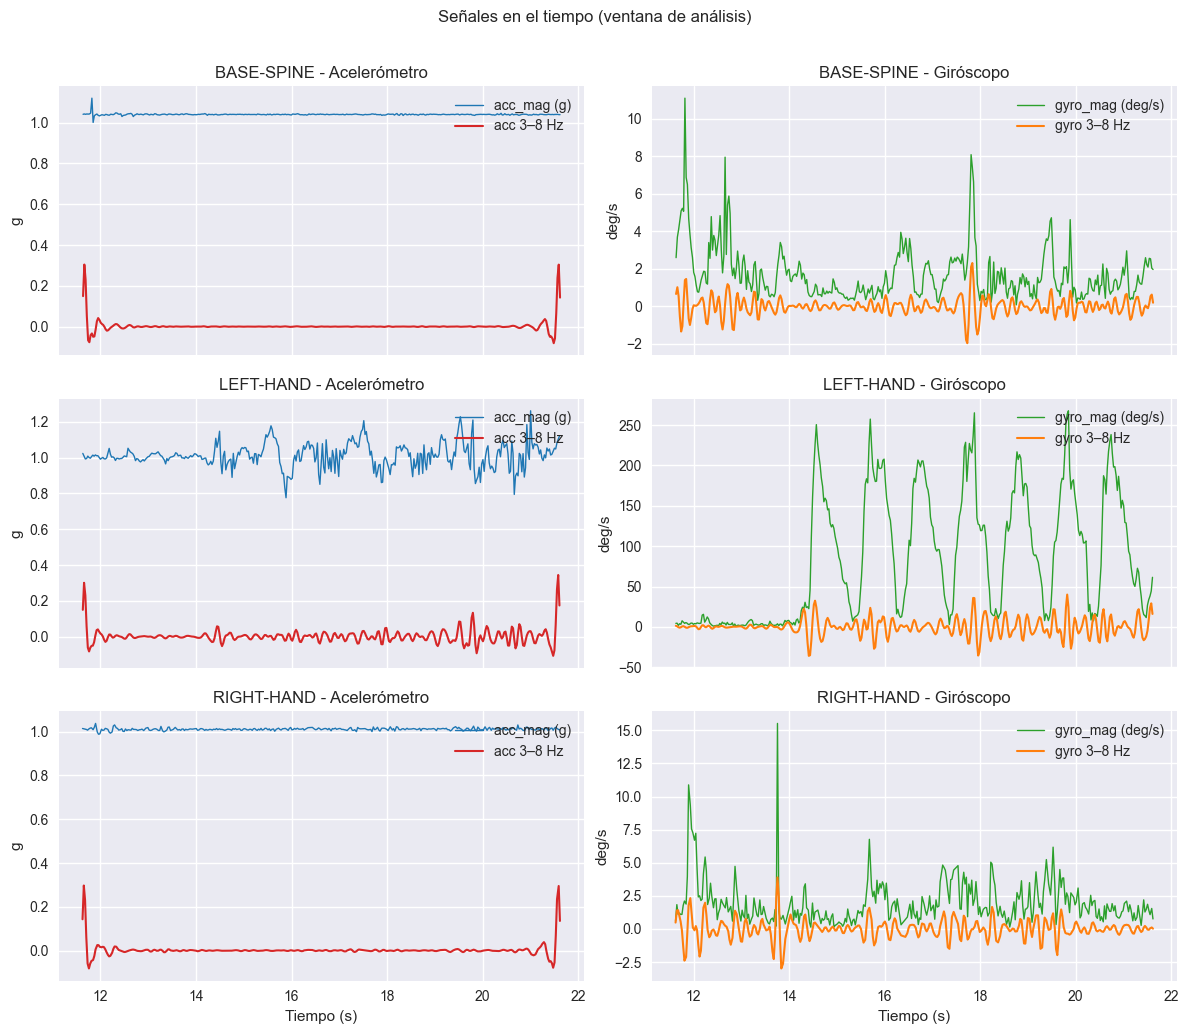

In [6]:
# Gráficos de tiempo con componente 3–8 Hz (mismo estilo que mano derecha)
if _USE_MPL:
    n = len(devices) if devices else 1
    fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(12, 3.5*n), sharex=True)
    if n == 1:
        axes = np.array([axes])
    for i, dev in enumerate(devices):
        sub = df_win[df_win['deviceId']==dev]
        t = sub['t'].to_numpy()
        acc = sub['acc_mag'].to_numpy()
        gyro = sub['gyro_mag'].to_numpy()
        fs = fs_map.get(dev, float('nan'))
        acc_trem = simple_bandpass(acc, fs, 3, 8) if np.isfinite(fs) and fs>0 else np.zeros_like(acc)
        gyro_trem = simple_bandpass(gyro, fs, 3, 8) if np.isfinite(fs) and fs>0 else np.zeros_like(gyro)
        ax0 = axes[i,0]
        ax0.plot(t, acc, color='#1f77b4', label='acc_mag (g)', linewidth=1)
        ax0.plot(t, acc_trem, color='#d62728', label='acc 3–8 Hz', linewidth=1.5)
        ax0.set_title(f"{dev} - Acelerómetro")
        ax0.set_ylabel('g')
        ax0.legend(loc='upper right')
        ax1 = axes[i,1]
        ax1.plot(t, gyro, color='#2ca02c', label='gyro_mag (deg/s)', linewidth=1)
        ax1.plot(t, gyro_trem, color='#ff7f0e', label='gyro 3–8 Hz', linewidth=1.5)
        ax1.set_title(f"{dev} - Giróscopo")
        ax1.set_ylabel('deg/s')
        ax1.legend(loc='upper right')
    for j in range(2):
        axes[-1,j].set_xlabel('Tiempo (s)')
    fig.suptitle('Señales en el tiempo (ventana de análisis)')
    fig.tight_layout(rect=[0,0,1,0.97])
    plt.show()
elif go is not None:
    for dev in devices:
        sub = df_win[df_win['deviceId']==dev]
        t = sub['t'].to_numpy()
        fs = fs_map.get(dev, float('nan'))
        acc = sub['acc_mag'].to_numpy()
        acc_trem = simple_bandpass(acc, fs, 3, 8) if np.isfinite(fs) and fs>0 else np.zeros_like(acc)
        fig1 = go.Figure()
        fig1.add_scatter(x=t, y=acc, name='acc_mag (g)')
        fig1.add_scatter(x=t, y=acc_trem, name='acc 3–8 Hz')
        fig1.update_layout(title=f'{dev} - Acelerómetro (ventana)', xaxis_title='Tiempo (s)', yaxis_title='g')
        fig1.show()
        gyro = sub['gyro_mag'].to_numpy()
        gyro_trem = simple_bandpass(gyro, fs, 3, 8) if np.isfinite(fs) and fs>0 else np.zeros_like(gyro)
        fig2 = go.Figure()
        fig2.add_scatter(x=t, y=gyro, name='gyro_mag (deg/s)')
        fig2.add_scatter(x=t, y=gyro_trem, name='gyro 3–8 Hz')
        fig2.update_layout(title=f'{dev} - Giróscopo (ventana)', xaxis_title='Tiempo (s)', yaxis_title='deg/s')
        fig2.show()
else:
    print('No hay backend de gráficos disponible.')

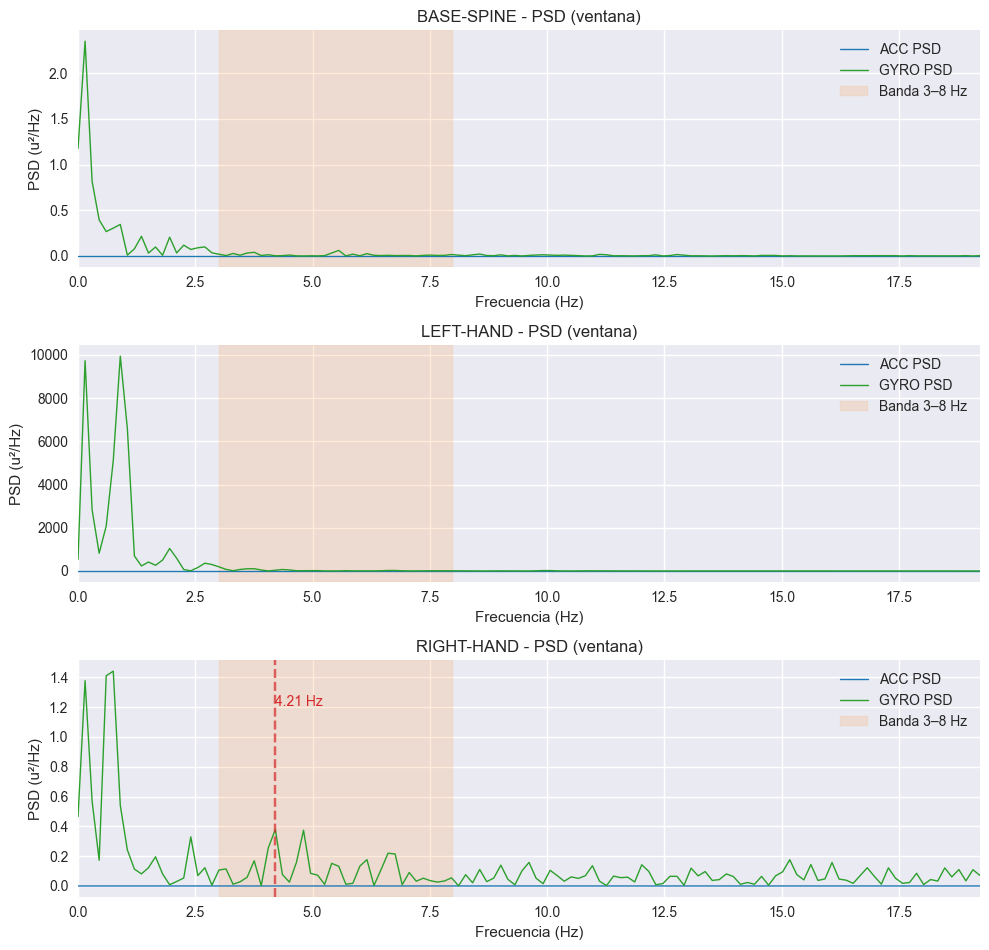

In [7]:
# PSD por dispositivo con banda 3–8 Hz (mismo estilo que mano derecha)
if _USE_MPL:
    n = len(devices) if devices else 1
    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(10, 3.2*n), sharex=False)
    axes = np.atleast_1d(axes).ravel()
    for i, dev in enumerate(devices):
        sub = df_win[df_win['deviceId']==dev]
        fs = fs_map.get(dev, float('nan'))
        acc = sub['acc_mag'].to_numpy() - np.mean(sub['acc_mag'].to_numpy())
        gyro = sub['gyro_mag'].to_numpy() - np.mean(sub['gyro_mag'].to_numpy())
        f_acc, P_acc = welch_psd(acc, fs=fs, nperseg=min(2048, max(256, len(acc)//2)))
        f_gyro, P_gyro = welch_psd(gyro, fs=fs, nperseg=min(2048, max(256, len(gyro)//2)))
        ax = axes[i]
        ax.plot(f_acc, P_acc, color='#1f77b4', lw=1, label='ACC PSD')
        ax.plot(f_gyro, P_gyro, color='#2ca02c', lw=1, label='GYRO PSD')
        ax.axvspan(3.0, 8.0, color='#ff7f0e', alpha=0.15, label='Banda 3–8 Hz')
        # marcar pico si se detectó
        det = [r for r in results if r.device==dev and r.is_tremor]
        if det:
            rbest = sorted(det, key=lambda r: r.ratio, reverse=True)[0]
            if np.isfinite(rbest.peak_freq_hz):
                ax.axvline(rbest.peak_freq_hz, color='#d62728', linestyle='--', alpha=0.7)
                ymax = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1.0
                ax.text(rbest.peak_freq_hz, ymax*0.8, f"{rbest.peak_freq_hz:.2f} Hz", color='#d62728')
        ax.set_xlim(0, min(20, (fs or 20)/2))
        ax.set_xlabel('Frecuencia (Hz)')
        ax.set_ylabel('PSD (u²/Hz)')
        ax.set_title(f'{dev} - PSD (ventana)')
        ax.legend(loc='upper right')
    fig.tight_layout()
    plt.show()
elif go is not None:
    for dev in devices:
        sub = df_win[df_win['deviceId']==dev]
        fs = fs_map.get(dev, float('nan'))
        acc = sub['acc_mag'].to_numpy() - np.mean(sub['acc_mag'].to_numpy())
        gyro = sub['gyro_mag'].to_numpy() - np.mean(sub['gyro_mag'].to_numpy())
        f_acc, P_acc = welch_psd(acc, fs=fs, nperseg=min(2048, max(256, len(acc)//2)))
        f_gyro, P_gyro = welch_psd(gyro, fs=fs, nperseg=min(2048, max(256, len(gyro)//2)))
        fig = go.Figure()
        fig.add_scatter(x=f_acc, y=P_acc, name='ACC PSD')
        fig.add_scatter(x=f_gyro, y=P_gyro, name='GYRO PSD')
        fig.update_layout(title=f'{dev} - PSD', xaxis_title='Frecuencia (Hz)', yaxis_title='PSD (u²/Hz)')
        fig.show()
else:
    print('No hay backend de gráficos disponible.')

In [8]:
# Resumen y conclusiones (misma salida que mano derecha)
def pretty_bool(b):
    return 'SÍ' if bool(b) else 'NO'

# Regla de fusión: 'gyro' | 'acc' | 'either' | 'both'
fusion_rule = 'gyro'  # por defecto decidimos por giroscopio
# rest_device_hint ya se definió en la celda de detección

if 'summary' in globals() and isinstance(summary, pd.DataFrame) and not summary.empty:
    display(summary[['device','signal','fs','peak_freq_hz','ratio','rms_tremor','is_tremor']].round(4))
    print('\nConclusiones por dispositivo (regla =', fusion_rule, ', control en reposo =', rest_device_hint, '):')
    for dev in devices:
        gyro_row = summary[(summary['device']==dev) & (summary['signal']=='gyro_mag')]
        acc_row  = summary[(summary['device']==dev) & (summary['signal']=='acc_mag')]
        gflag = bool(gyro_row['is_tremor'].iloc[0]) if not gyro_row.empty else False
        aflag = bool(acc_row['is_tremor'].iloc[0]) if not acc_row.empty else False
        pf_g  = float(gyro_row['peak_freq_hz'].iloc[0]) if not gyro_row.empty else float('nan')
        pf_a  = float(acc_row['peak_freq_hz'].iloc[0]) if not acc_row.empty else float('nan')
        if fusion_rule == 'gyro':
            final_flag = gflag
        elif fusion_rule == 'acc':
            final_flag = aflag
        elif fusion_rule == 'either':
            final_flag = gflag or aflag
        elif fusion_rule == 'both':
            final_flag = gflag and aflag
        else:
            final_flag = gflag
        # Nota según reposo/actividad
        if dev == rest_device_hint:
            ctx = ' (reposo/control) '
        else:
            ctx = ''
        if final_flag:
            if gflag and not aflag:
                note = 'Temblor detectado principalmente en GIROSCOPIO; amplitud lineal baja (típico en temblor leve).'+ctx
            elif aflag and not gflag:
                note = 'Temblor detectado en ACELERÓMETRO; revisar ruido/artefactos en gyro.'+ctx
            else:
                note = 'Temblor detectado en ambos canales.'+ctx
        else:
            note = 'No detectado según criterios actuales.'+ctx
        print(f" - {dev}: Temblor={pretty_bool(final_flag)} | gyro={pretty_bool(gflag)} (f={pf_g:.2f}Hz) | acc={pretty_bool(aflag)} (f={pf_a:.2f}Hz) -> {note}")
else:
    print('No hay resultados para mostrar.')

,device,signal,fs,peak_freq_hz,ratio,rms_tremor,is_tremor
0,BASE-SPINE,acc_mag,38.4615,3.9062,0.3591,0.0322,False
1,BASE-SPINE,gyro_mag,38.4615,3.0048,0.2137,0.4637,False
2,LEFT-HAND,acc_mag,38.4615,3.6058,0.0897,0.0418,False
3,LEFT-HAND,gyro_mag,38.4615,3.0048,0.0315,10.6280,False
4,RIGHT-HAND,acc_mag,38.4615,3.9062,0.3764,0.0340,False
5,RIGHT-HAND,gyro_mag,38.4615,4.2067,0.3702,0.7619,True



Conclusiones por dispositivo (regla = gyro , control en reposo = RIGHT-HAND ):
 - BASE-SPINE: Temblor=NO | gyro=NO (f=3.00Hz) | acc=NO (f=3.91Hz) -> No detectado según criterios actuales.
 - LEFT-HAND: Temblor=NO | gyro=NO (f=3.00Hz) | acc=NO (f=3.61Hz) -> No detectado según criterios actuales.
 - RIGHT-HAND: Temblor=SÍ | gyro=SÍ (f=4.21Hz) | acc=NO (f=3.91Hz) -> Temblor detectado principalmente en GIROSCOPIO; amplitud lineal baja (típico en temblor leve). (reposo/control) 


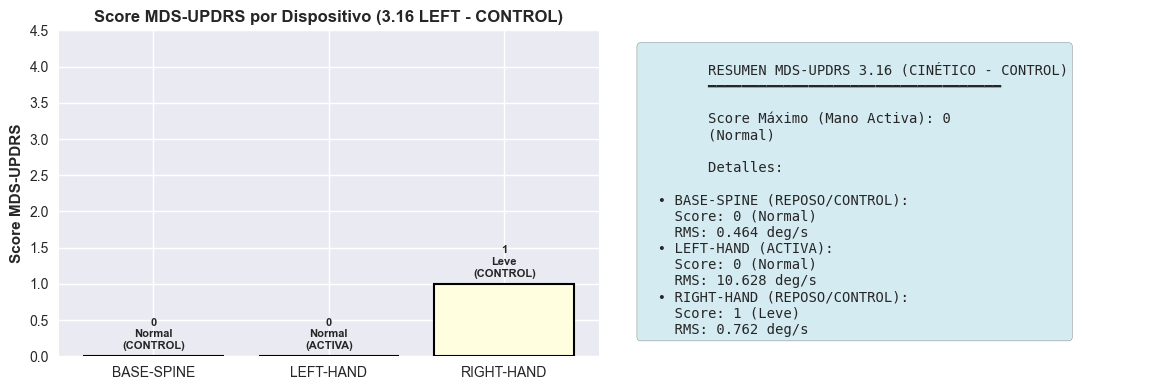


SCORES MDS-UPDRS 3.16 (CINÉTICO - LEFT CONTROL)
BASE-SPINE      [CONTROL]  | Score: 0 (Normal         ) | RMS: 0.4637
LEFT-HAND       [ACTIVA]   | Score: 0 (Normal         ) | RMS: 10.6280
RIGHT-HAND      [CONTROL]  | Score: 1 (Leve           ) | RMS: 0.7619
MÁXIMO (ACTIVA)           | Score: 0


In [9]:

# IAG: Logica de clasificacion MDS-UPDRS asistida por IAG segun rangos definidos por el tutor.
# ============================================================================
# CÁLCULO DE SCORE MDS-UPDRS 3.16 (Temblor Cinético - Mano Izquierda / CONTROL)
# ============================================================================
# Score 0: Normal (sin temblor)
# Score 1: Leve (temblor detectado, gyro_rms < 1.0 deg/s)
# Score 2: Moderado-leve (1.0 ≤ gyro_rms < 3.0 deg/s)
# Score 3: Moderado (3.0 ≤ gyro_rms < 8.0 deg/s)
# Score 4: Severo (gyro_rms ≥ 8.0 deg/s)

def calculate_mds_updrs_score(gyro_rms: float, tremor_detected: bool) -> tuple:
    """Calcula score MDS-UPDRS (0-4) y etiqueta descriptiva."""
    if not tremor_detected:
        return (0, "Normal")
    if gyro_rms < 1.0:
        return (1, "Leve")
    elif gyro_rms < 3.0:
        return (2, "Moderado-leve")
    elif gyro_rms < 8.0:
        return (3, "Moderado")
    else:
        return (4, "Severo")

# Procesar scores por dispositivo
if 'summary' in globals() and isinstance(summary, pd.DataFrame) and not summary.empty:
    scores_by_device = {}
    
    for dev in summary['device'].unique():
        dev_data = summary[summary['device'] == dev]
        gyro_data = dev_data[dev_data['signal'] == 'gyro_mag']
        
        if not gyro_data.empty:
            gyro_rms = gyro_data['rms_tremor'].iloc[0]
            tremor_detected = gyro_data['is_tremor'].iloc[0]
            score, label = calculate_mds_updrs_score(gyro_rms, tremor_detected)
            scores_by_device[dev] = {'score': score, 'label': label, 'gyro_rms': gyro_rms}
    
    # Score máximo de la mano ACTIVA (LEFT-HAND en este caso)
    max_score = scores_by_device.get('LEFT-HAND', {}).get('score', 0)
    
    # Dashboard visual
    if _USE_MPL:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        
        # Gráfico 1: Scores por dispositivo
        devices = list(scores_by_device.keys())
        scores = [scores_by_device[d]['score'] for d in devices]
        colors = []
        for dev, score in zip(devices, scores):
            if dev == 'LEFT-HAND':  # Mano activa
                colors.append('darkgreen' if score == 0 else 'gold' if score in [1, 2] else 'darkorange' if score == 3 else 'darkred')
            else:  # Mano en reposo/control
                colors.append('lightgreen' if score == 0 else 'lightyellow' if score in [1, 2] else 'lightcoral' if score == 3 else 'lightpink')
        
        bars = ax1.bar(devices, scores, color=colors, edgecolor='black', linewidth=1.5)
        ax1.set_ylabel('Score MDS-UPDRS', fontsize=11, fontweight='bold')
        ax1.set_ylim(0, 4.5)
        ax1.set_title('Score MDS-UPDRS por Dispositivo (3.16 LEFT - CONTROL)', fontweight='bold')
        ax1.axhline(y=0, color='k', linewidth=0.5)
        for i, (dev, score) in enumerate(zip(devices, scores)):
            label = scores_by_device[dev]['label']
            role = '(ACTIVA)' if dev == 'LEFT-HAND' else '(CONTROL)'
            ax1.text(i, score + 0.1, f"{score}\n{label}\n{role}", ha='center', fontsize=8, fontweight='bold')
        
        # Gráfico 2: Resumen global
        ax2.axis('off')
        summary_text = f"""
        RESUMEN MDS-UPDRS 3.16 (CINÉTICO - CONTROL)
        ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
        
        Score Máximo (Mano Activa): {max_score}
        ({['Normal', 'Leve', 'Moderado-leve', 'Moderado', 'Severo'][max_score]})
        
        Detalles:
        """
        for dev, data in sorted(scores_by_device.items()):
            role = '(ACTIVA)' if dev == 'LEFT-HAND' else '(REPOSO/CONTROL)'
            summary_text += f"\n  • {dev} {role}:"
            summary_text += f"\n    Score: {data['score']} ({data['label']})"
            summary_text += f"\n    RMS: {data['gyro_rms']:.3f} deg/s"
        
        ax2.text(0.05, 0.95, summary_text, transform=ax2.transAxes, fontsize=10,
                verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
        
        plt.tight_layout()
        plt.show()
        
        print("\n" + "="*60)
        print("SCORES MDS-UPDRS 3.16 (CINÉTICO - LEFT CONTROL)")
        print("="*60)
        for dev, data in sorted(scores_by_device.items()):
            role = '[ACTIVA]' if dev == 'LEFT-HAND' else '[CONTROL]'
            print(f"{dev:15} {role:10} | Score: {data['score']} ({data['label']:15s}) | RMS: {data['gyro_rms']:.4f}")
        print(f"{'MÁXIMO (ACTIVA)':25} | Score: {max_score}")
        print("="*60)
    else:
        print("\n" + "="*60)
        print("SCORES MDS-UPDRS 3.16 (CINÉTICO - LEFT CONTROL)")
        print("="*60)
        for dev, data in sorted(scores_by_device.items()):
            role = '[ACTIVA]' if dev == 'LEFT-HAND' else '[CONTROL]'
            print(f"{dev:15} {role:10} | Score: {data['score']} ({data['label']:15s}) | RMS: {data['gyro_rms']:.4f}")
        print(f"{'MÁXIMO (ACTIVA)':25} | Score: {max_score}")
        print("="*60)
else:
    print("No hay datos de 'summary' disponibles. Ejecute las celdas anteriores primero.")

## Interpretación para esta tarea

- LEFT-HAND realiza una tarea de movimiento voluntario (tocar nariz), por lo que pueden aparecer componentes lentas (<2 Hz) asociadas al ciclo del movimiento. El detector de temblor se enfoca en 3–8 Hz para separar el temblor del movimiento voluntario.
- RIGHT-HAND está en reposo y sirve como control: idealmente mostrará menor potencia en 3–8 Hz. Si muestra temblor en reposo, puede indicar temblor contralateral.
- BASE-SPINE ayuda a identificar transmisión global/artefactos. Una energía 3–8 Hz menor que en la mano evaluada sugiere temblor periférico.
